<a href="https://colab.research.google.com/github/sreelakshmipmmm/Rainfall-Analysis-of-Indian-Meteorological-Sub-Divisions./blob/main/Rainfall_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Rainfall Analysis of Indian Meteorological Sub-Divisions**

###**Introduction**

Rainfall plays a crucial role in India’s environmental stability, agricultural productivity, water resource management, and overall economic resilience. Variations in rainfall patterns—especially those related to the monsoon—can lead to severe consequences such as floods, droughts, crop failures, and long-term climate stress across different regions of the country.

This project focuses on the analysis of historical rainfall data across various meteorological sub-divisions of India. The dataset contains year-wise and month-wise rainfall measurements, enabling the study of seasonal behavior, long-term trends, and deviations from normal rainfall patterns. By performing data cleaning, feature engineering, and exploratory data analysis, the project aims to identify meaningful patterns related to monsoon dependence and rainfall anomalies across regions and time periods.

Python libraries such as Pandas, NumPy, and Matplotlib are used to preprocess the data and extract insights that highlight regional variability and temporal changes in rainfall characteristics.

###**Data Source**

The dataset used in this project was obtained from the India Meteorological Department (IMD) and published through the Government of India’s open data platform. IMD is the official authority responsible for meteorological observations in India, and the dataset provides reliable, long-term rainfall records collected across multiple decades for different meteorological sub-divisions.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


*The necessary Python libraries are imported to support data handling, numerical computation, and visualization.  
Pandas and NumPy are used for data manipulation and calculations, while Matplotlib and Seaborn are used for visualizing rainfall patterns and trends.*


###**Data Loading**

In [ ]:
df = pd.read_csv("Sub_Division_IMD_2017.csv")
#Loading the IMD sub-division rainfall dataset into a pandas DataFrame.

###**Dataset Overview**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SUBDIVISION  4188 non-null   object 
 1   YEAR         4188 non-null   int64  
 2   JAN          4184 non-null   float64
 3   FEB          4185 non-null   float64
 4   MAR          4182 non-null   float64
 5   APR          4184 non-null   float64
 6   MAY          4185 non-null   float64
 7   JUN          4183 non-null   float64
 8   JUL          4181 non-null   float64
 9   AUG          4184 non-null   float64
 10  SEP          4182 non-null   float64
 11  OCT          4181 non-null   float64
 12  NOV          4177 non-null   float64
 13  DEC          4178 non-null   float64
 14  ANNUAL       4162 non-null   float64
 15  JF           4182 non-null   float64
 16  MAM          4179 non-null   float64
 17  JJAS         4178 non-null   float64
 18  OND          4175 non-null   float64
dtypes: flo

In [ ]:
df.head()
#Shows first 5 rows of dataset

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,Andaman & Nicobar Islands,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,Andaman & Nicobar Islands,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,Andaman & Nicobar Islands,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,Andaman & Nicobar Islands,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,Andaman & Nicobar Islands,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


###**Data Cleaning and Preprocessing**

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)
#Standardizes column names by removing extra spaces and converting them to lowercase for consistency and ease of access.

In [ ]:
df.columns


Index(['subdivision', 'year', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul',
       'aug', 'sep', 'oct', 'nov', 'dec', 'annual', 'jf', 'mam', 'jjas',
       'ond'],
      dtype='object')

In [ ]:
df.describe()

,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,annual,jf,mam,jjas,ond
count,4188.000000,4184.000000,4185.000000,4182.000000,4184.000000,4185.000000,4183.000000,4181.000000,4184.000000,4182.000000,4181.000000,4177.000000,4178.000000,4162.000000,4182.000000,4179.000000,4178.000000,4175.000000
mean,1959.220630,18.938337,21.599427,27.412912,43.071845,85.660860,230.117475,347.020043,289.742185,197.316332,95.324707,39.496433,18.968645,1409.449207,40.522979,155.820914,1063.851580,153.648623
std,33.717097,33.793128,35.731734,46.927963,68.150985,122.695137,234.292087,268.850702,188.426071,135.547646,99.194851,68.358706,43.053759,902.599421,59.293904,201.198627,706.666045,166.863171
min,1901.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,62.300000,0.000000,0.000000,57.400000,0.000000
25%,1930.000000,0.600000,0.500000,1.000000,3.000000,8.600000,70.800000,175.600000,155.850000,100.400000,14.600000,0.600000,0.100000,803.025000,4.000000,24.000000,573.850000,34.000000
50%,1959.000000,5.950000,6.500000,7.900000,15.450000,36.900000,138.800000,285.000000,258.500000,173.700000,65.200000,9.400000,3.000000,1120.350000,18.900000,74.800000,880.600000,97.700000
75%,1988.000000,22.000000,26.600000,31.375000,49.650000,97.800000,305.000000,418.500000,377.625000,266.125000,148.300000,45.300000,17.500000,1643.575000,50.175000,196.950000,1287.450000,211.800000
max,2017.000000,583.700000,403.500000,605.600000,595.100000,1168.600000,1609.900000,2362.800000,1664.600000,1222.000000,948.300000,648.900000,617.500000,6331.100000,699.500000,1745.800000,4536.900000,1252.500000


*Summary statistics are generated to understand the distribution, central tendency, and variability of numerical rainfall values.*


In [ ]:
rain_cols = [
    'jan','feb','mar','apr','may',
    'jun','jul','aug','sep',
    'oct','nov','dec','annual'
]

df[rain_cols].isna().sum()

,0
jan,4
feb,3
mar,6
apr,4
may,3
jun,5
jul,7
aug,4
sep,6
oct,7


*Creates a reusable list of monthly rainfall columns to simplify later operations.  
Missing values in these columns are then identified to assess data completeness.*


In [ ]:
df['annual'] = df['annual'].fillna(
    df[['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']].sum(axis=1)
)

*Missing annual rainfall values are filled by recalculating them as the sum of available monthly rainfall values for each year.*

In [ ]:
for month in ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']:
    df[month] = df[month].fillna(
        df.groupby('subdivision')[month].transform('mean')
    )

*Missing monthly rainfall values are filled using the mean rainfall of the corresponding subdivision.  
This helps preserve regional rainfall patterns while handling missing data.*

###**Feature Engineering**

In [ ]:
df['jf'] = df[['jan', 'feb']].sum(axis=1)
df['mam'] = df[['mar', 'apr', 'may']].sum(axis=1)
df['jjas'] = df[['jun', 'jul', 'aug', 'sep']].sum(axis=1)
df['ond'] = df[['oct', 'nov', 'dec']].sum(axis=1)

*Seasonal rainfall totals are recalculated from monthly values to ensure consistency and eliminate remaining missing values.*

In [ ]:
df['monsoon_rainfall_calc'] = df[['jun','jul','aug','sep']].sum(axis=1)
df['non_monsoon_rainfall'] = df['annual'] - df['monsoon_rainfall_calc']
df['monsoon_percentage'] = (df['monsoon_rainfall_calc'] / df['annual']) * 100

*Additional features are created to quantify monsoon and non-monsoon rainfall and to measure the proportion of annual rainfall contributed by the monsoon season.*

In [ ]:
df['mean_annual_rainfall'] = (
    df.groupby('subdivision')['annual'].transform('mean')
)

df['mean_monsoon_rainfall'] = (
    df.groupby('subdivision')['monsoon_rainfall_calc'].transform('mean')
)

df['annual_anomaly'] = df['annual'] - df['mean_annual_rainfall']
df['monsoon_anomaly'] = df['monsoon_rainfall_calc'] - df['mean_monsoon_rainfall']

*Long-term mean annual and monsoon rainfall values are computed for each subdivision.  
Rainfall anomalies are then calculated as deviations from these long-term averages.*

In [ ]:
df['rainfall_category'] = pd.cut(
    df['annual'],
    bins=[0, 750, 1250, 2000, np.inf],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

*Annual rainfall values are categorized into intensity levels to enable categorical analysis and comparison across regions and years.*

In [ ]:
df['monsoon_dominant'] = df['monsoon_percentage'] > 70

*A binary indicator is created to identify years in which a subdivision receives the majority of its rainfall from the monsoon season.*

In [ ]:
df['extreme_rainfall_year'] = abs(df['annual_anomaly']) > df['annual_anomaly'].std()

*Extreme rainfall years are identified based on large deviations from long-term annual rainfall averages, highlighting anomalous climatic events.*


In [ ]:
df['decade'] = (df['year'] // 10) * 10

*A decade-based column is created to facilitate long-term temporal trend analysis of rainfall patterns.*

In [ ]:
df.isna().sum()


,0
subdivision,0
year,0
jan,0
feb,0
mar,0
apr,0
may,0
jun,0
jul,0
aug,0


In [ ]:
df.to_csv("Rainfall_cleaned.csv", index=False)

###**Exploratory Data Analysis**

In [ ]:
sns.set_theme(
    style="whitegrid",
    context="talk",
    palette="viridis"
)

####**Univariate Analysis~~**

**Distribution of Annual Rainfall**

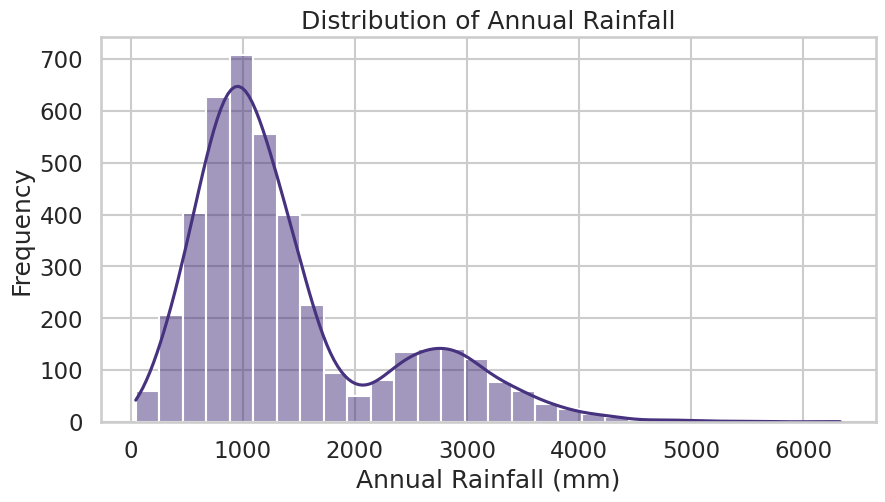

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['annual'], bins=30, kde=True)

plt.title('Distribution of Annual Rainfall')
plt.xlabel('Annual Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()

*The distribution of annual rainfall shows noticeable variability across years and regions.  
The data appears slightly right-skewed, indicating that while most years receive moderate rainfall, a few years experience exceptionally high rainfall.  
This suggests the presence of extreme rainfall events, which are important to consider in climate variability analysis.*


**Distribution of Monsoon Percentage**

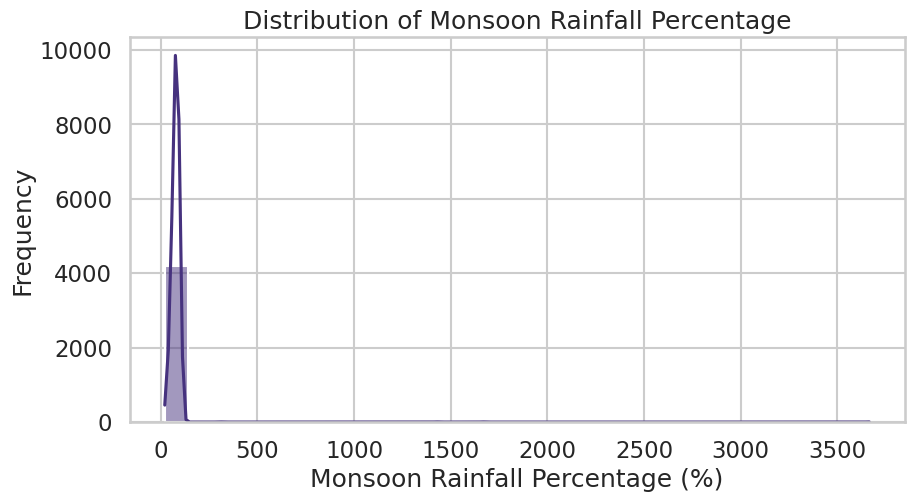

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['monsoon_percentage'], bins=30, kde=True)
plt.title('Distribution of Monsoon Rainfall Percentage')
plt.xlabel('Monsoon Rainfall Percentage (%)')
plt.ylabel('Frequency')
plt.show()


*The distribution of monsoon rainfall percentage indicates that a large proportion of annual rainfall is contributed by the monsoon season.  
Most observations are concentrated at higher percentage values, highlighting the strong dependence of rainfall on monsoon patterns.  
This emphasizes the critical role of monsoon variability in influencing overall rainfall levels.*

**Share of Monsoon vs Non-Monsoon Rainfall**

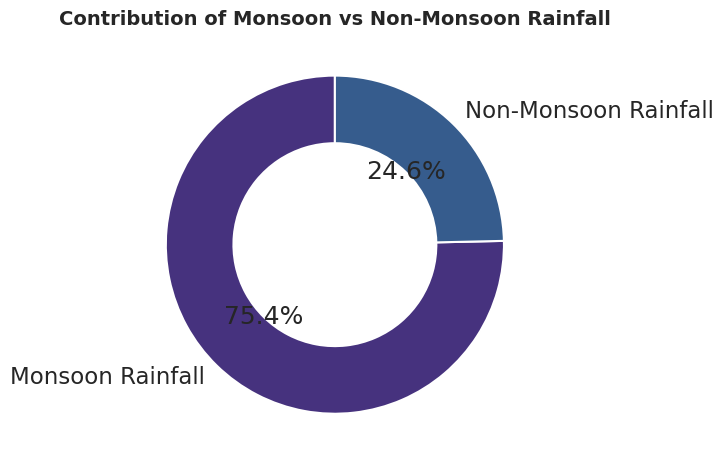

In [ ]:
monsoon_total = df['monsoon_rainfall_calc'].sum()
non_monsoon_total = df['non_monsoon_rainfall'].sum()

labels = ['Monsoon Rainfall', 'Non-Monsoon Rainfall']
sizes = [monsoon_total, non_monsoon_total]

plt.figure(figsize=(10,5))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.title('Contribution of Monsoon vs Non-Monsoon Rainfall', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


*The donut chart highlights the dominant contribution of monsoon rainfall to total annual rainfall.  
A substantial majority of precipitation occurs during the monsoon months, emphasizing India’s strong dependence on the southwest monsoon.  
Any variability or failure in monsoon patterns can therefore have a significant impact on water availability and agriculture.*


**Rainfall Category Distribution**

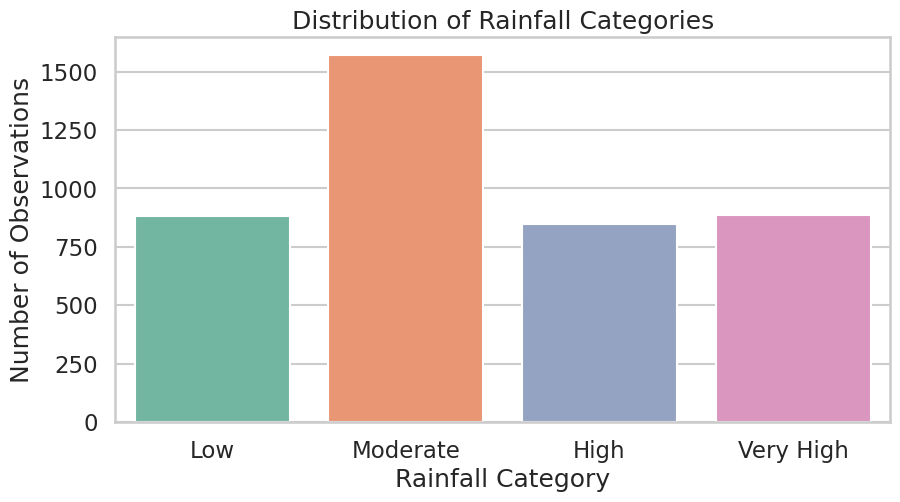

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='rainfall_category',
    hue='rainfall_category',
    data=df,
    palette='Set2',
    legend=False
)
plt.title('Distribution of Rainfall Categories')
plt.xlabel('Rainfall Category')
plt.ylabel('Number of Observations')
plt.show()

*The bar chart shows that most years fall under the Moderate rainfall category, while Low, High and Very High rainfall years are comparatively fewer.  
This indicates that extreme rainfall conditions occur less frequently, whereas moderate rainfall levels are more common across subdivisions and years.  
Such categorization helps simplify rainfall variability for comparative analysis.*

**Box Plot of Annual Rainfall (Outlier Detection)**

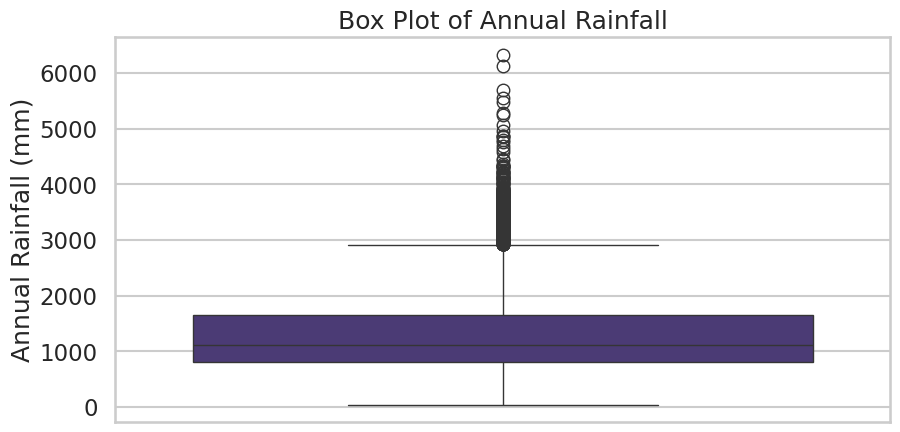

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(y=df['annual'])
plt.title('Box Plot of Annual Rainfall')
plt.ylabel('Annual Rainfall (mm)')
plt.show()

*The box plot reveals the presence of several extreme rainfall values beyond the upper whisker, indicating years with unusually high rainfall.  
These outliers likely correspond to extreme climatic events such as floods or intense monsoon seasons.  
Rather than removing them, these values are retained for analysis, as they are climatologically significant.*

**Annual Rainfall Trend Over Time (All-India Average)**

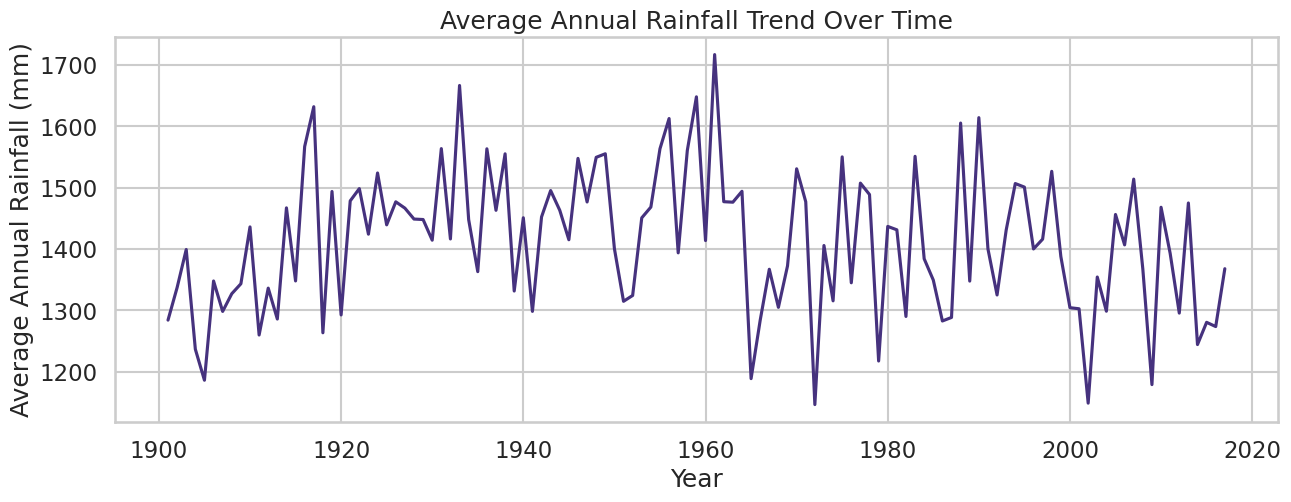

In [ ]:
annual_trend = df.groupby('year')['annual'].mean()

plt.figure(figsize=(15,5))
plt.plot(annual_trend.index, annual_trend.values)
plt.title('Average Annual Rainfall Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Average Annual Rainfall (mm)')
plt.show()

*The line plot shows year-to-year fluctuations in average annual rainfall, indicating significant inter-annual variability.  
While no strong long-term increasing or decreasing trend is clearly visible, the variability suggests sensitivity of rainfall patterns to climatic factors.  
This highlights the importance of analyzing rainfall trends over extended periods.*

####**Bivariate Analysis~~**

**Mean Annual Rainfall by Subdivision**

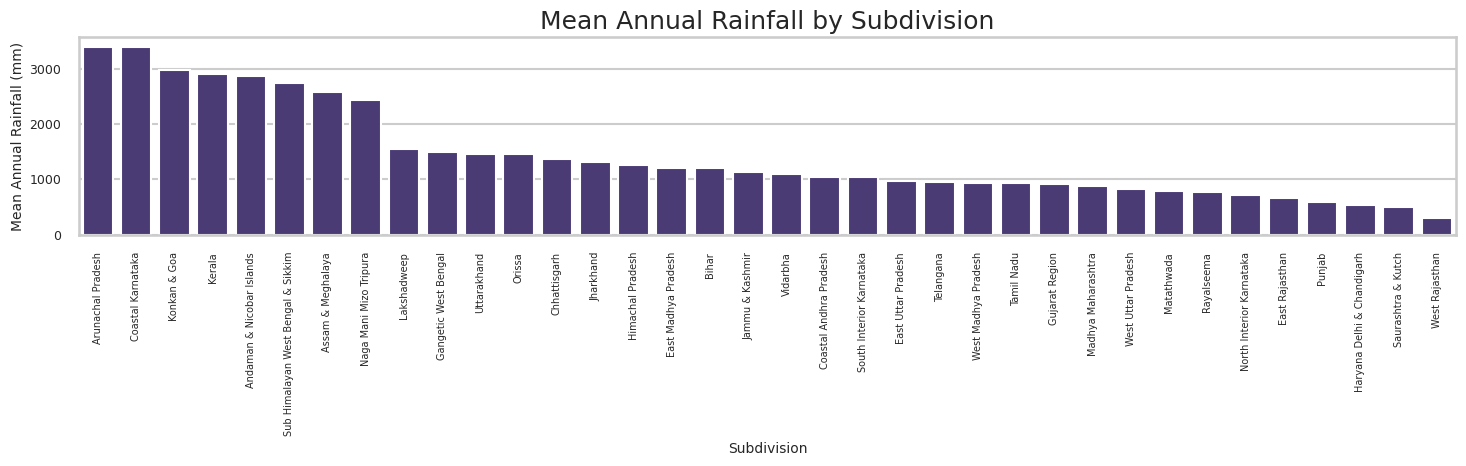

In [ ]:
plt.figure(figsize=(15,5))
subdivision_mean = df.groupby('subdivision')['annual'].mean().sort_values(ascending=False)

sns.barplot(
    x=subdivision_mean.index,
    y=subdivision_mean.values
)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=9)
plt.title('Mean Annual Rainfall by Subdivision')
plt.xlabel('Subdivision', fontsize=10)
plt.ylabel('Mean Annual Rainfall (mm)', fontsize=10)
plt.tight_layout()
plt.show()


*The bar chart shows substantial regional variation in mean annual rainfall across subdivisions.  
Subdivisions located along the western coast and northeastern regions record significantly higher rainfall compared to inland and northwestern regions.  
This highlights the strong influence of geography and monsoon pathways on rainfall distribution in India.*

**Mean Monsoon Rainfall by Subdivision**

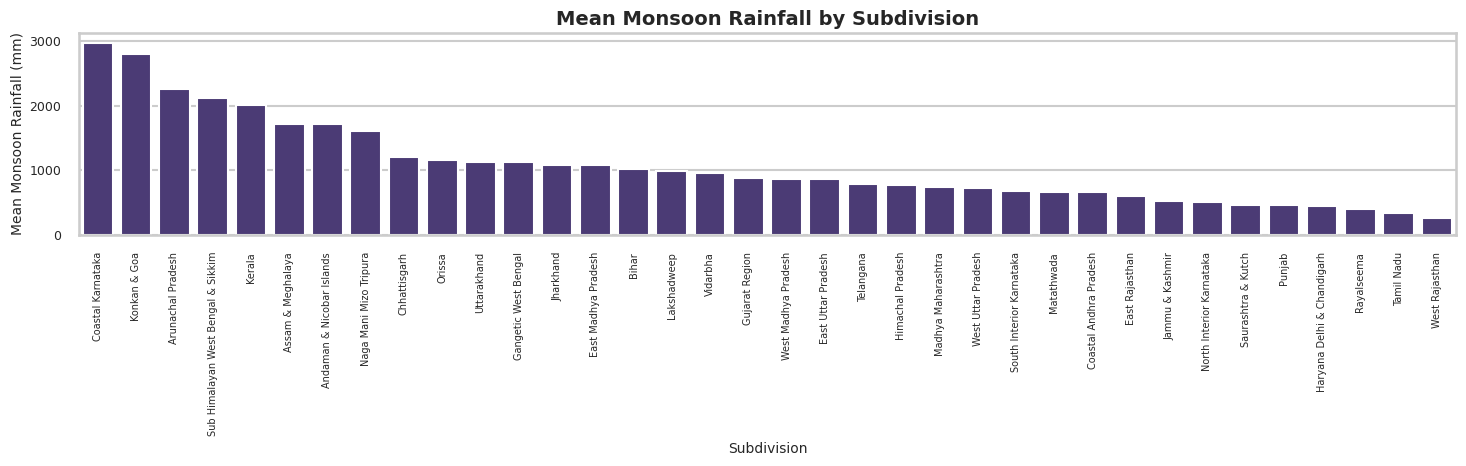

In [ ]:
plt.figure(figsize=(15,5))

subdivision_monsoon_mean = (
    df.groupby('subdivision')['monsoon_rainfall_calc']
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=subdivision_monsoon_mean.index,
    y=subdivision_monsoon_mean.values
)

plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=9)

plt.title('Mean Monsoon Rainfall by Subdivision', fontsize=14, weight='bold')
plt.xlabel('Subdivision', fontsize=10)
plt.ylabel('Mean Monsoon Rainfall (mm)', fontsize=10)

plt.tight_layout()
plt.show()



*The plot indicates that subdivisions with high annual rainfall also tend to receive substantial rainfall during the monsoon season.  
Coastal and northeastern subdivisions show particularly high monsoon rainfall, emphasizing their strong reliance on monsoon systems.  
This pattern reinforces the dominant role of the southwest monsoon in shaping regional rainfall characteristics.*

**Relationship Between Annual Rainfall and Monsoon Rainfall**

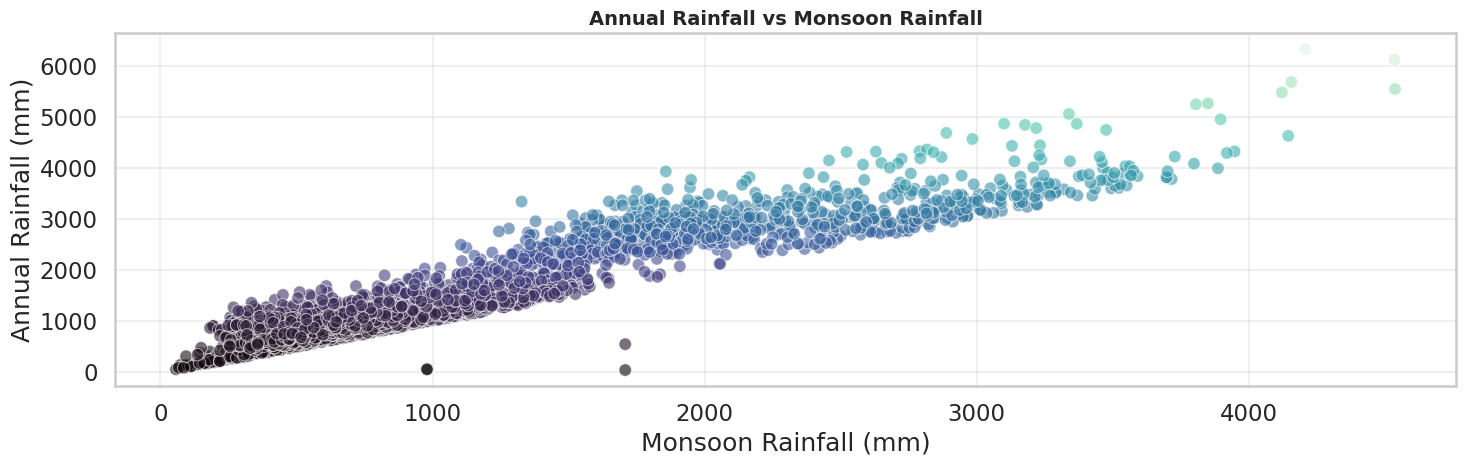

In [ ]:
plt.figure(figsize=(15,5))
sns.scatterplot(
    x='monsoon_rainfall_calc',
    y='annual',
    data=df,
    alpha=0.6,
    palette='mako',hue='annual', legend=False
)
plt.title('Annual Rainfall vs Monsoon Rainfall', fontsize=14, weight='bold')
plt.xlabel('Monsoon Rainfall (mm)')
plt.ylabel('Annual Rainfall (mm)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


*The scatter plot shows a strong positive relationship between monsoon rainfall and annual rainfall.  
As monsoon rainfall increases, annual rainfall also rises, indicating that the monsoon season contributes substantially to total yearly rainfall.  
This confirms the dominant role of the monsoon in shaping annual rainfall patterns across subdivisions.*

**Annual Rainfall by Rainfall Category**

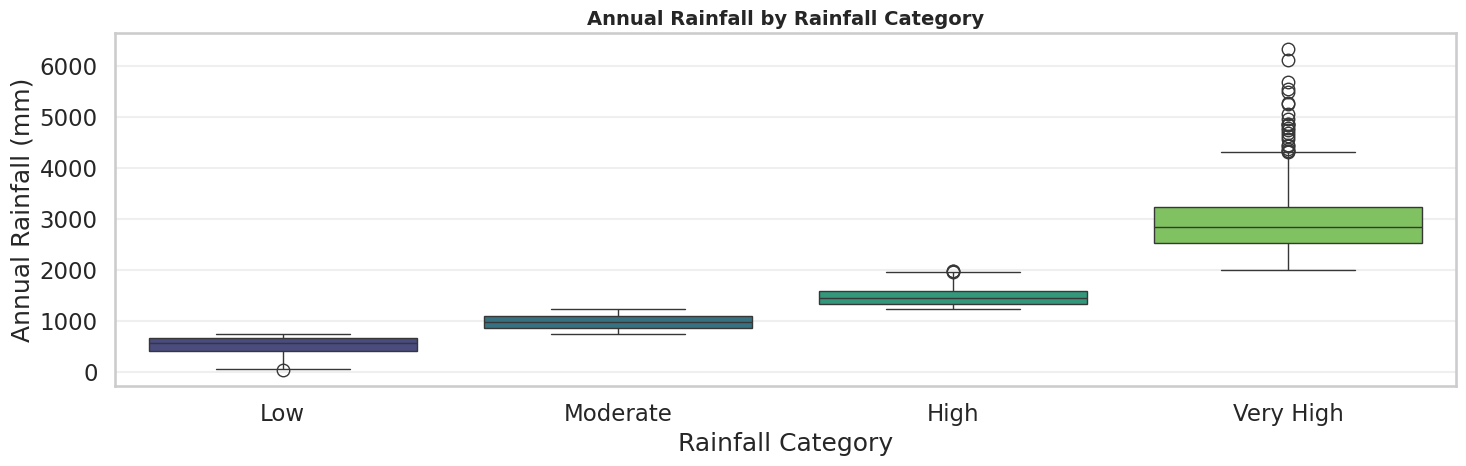

In [ ]:
plt.figure(figsize=(15,5))
sns.boxplot(
    x='rainfall_category',
    y='annual',
    data=df,
    palette='viridis',hue='rainfall_category', legend=False
)
plt.title('Annual Rainfall by Rainfall Category', fontsize=14, weight='bold')
plt.xlabel('Rainfall Category')
plt.ylabel('Annual Rainfall (mm)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


*The box plot shows a clear separation between rainfall categories, with median rainfall increasing consistently from Low to Very High categories.  
Higher categories also exhibit greater variability, indicating that extreme rainfall years tend to be more dispersed.  
This confirms that the rainfall categorization effectively captures differences in annual rainfall intensity.*

**Decade-wise Average Annual Rainfall**

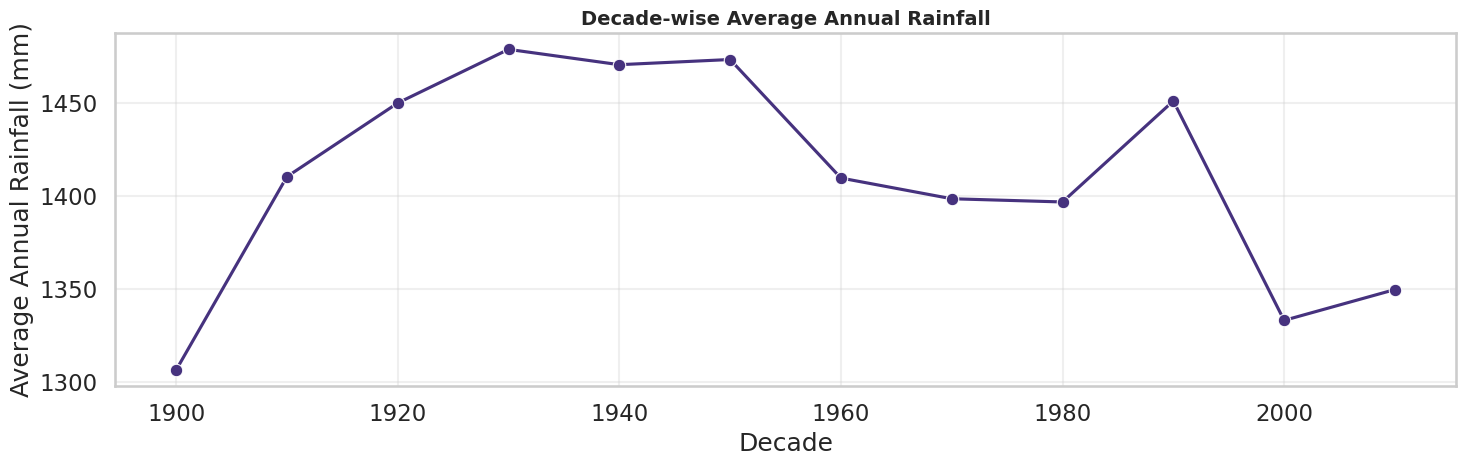

In [ ]:
decade_mean = df.groupby('decade')['annual'].mean()

plt.figure(figsize=(15,5))
sns.lineplot(
    x=decade_mean.index,
    y=decade_mean.values,
    marker='o'
)
plt.title('Decade-wise Average Annual Rainfall', fontsize=14, weight='bold')
plt.xlabel('Decade')
plt.ylabel('Average Annual Rainfall (mm)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


*The line plot shows noticeable fluctuations in average annual rainfall across decades.  
Some decades experience higher mean rainfall, while others show relative declines, indicating long-term variability.  
This suggests that rainfall patterns are influenced by multi-decadal climatic factors rather than short-term changes alone.*

####**Multivariate Analysis~~**

**Correlation Heatmap of Rainfall Features**

In [ ]:
heatmap_cols = [
    'annual','jf','mam','jjas','ond',
    'monsoon_rainfall_calc','non_monsoon_rainfall',
    'monsoon_percentage','annual_anomaly','monsoon_anomaly'
]

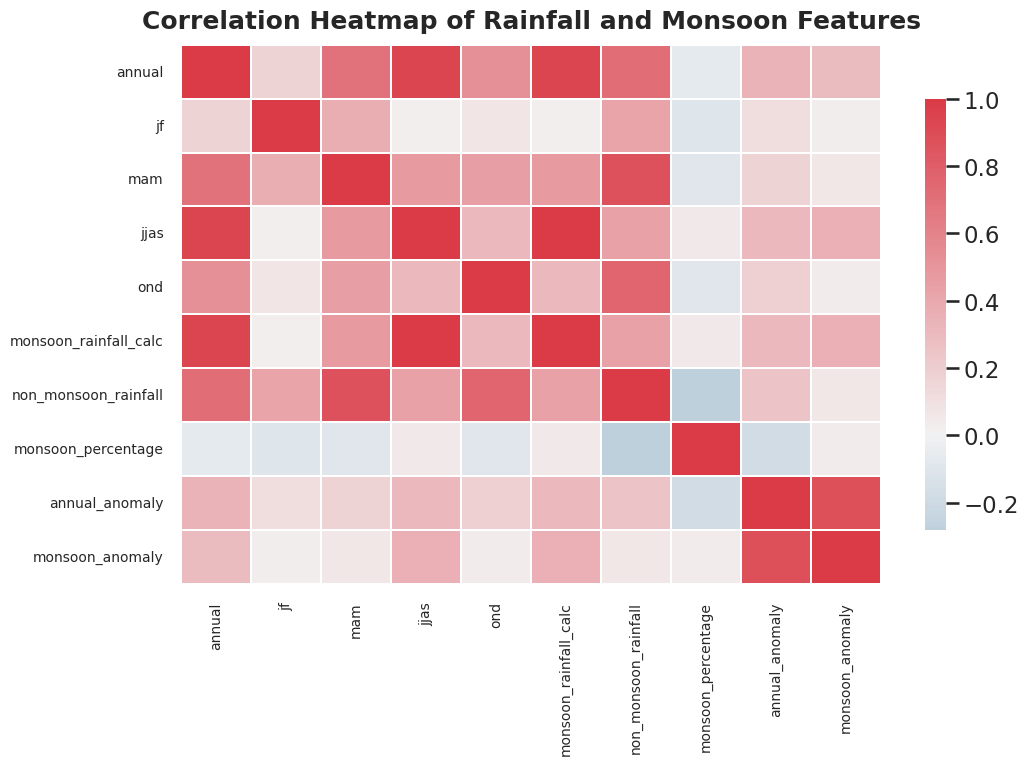

In [ ]:
sns.set_theme(style="white", context="talk")

plt.figure(figsize=(11,8))
sns.heatmap(
    df[heatmap_cols].corr(),
    cmap = sns.diverging_palette(240, 10, as_cmap=True),
    center=0,
    annot=False,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'shrink': 0.8}
)

plt.title(
    'Correlation Heatmap of Rainfall and Monsoon Features',
    fontsize=18,
    weight='bold',
    pad=12
)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


*The correlation heatmap shows strong positive relationships between annual rainfall and monsoon-related variables such as JJAS rainfall and monsoon rainfall contribution.  
Non-monsoon rainfall shows weaker correlations, indicating that annual rainfall variability is largely driven by monsoon performance.*

**Mean Monsoon vs Mean Annual Rainfall by Subdivision**

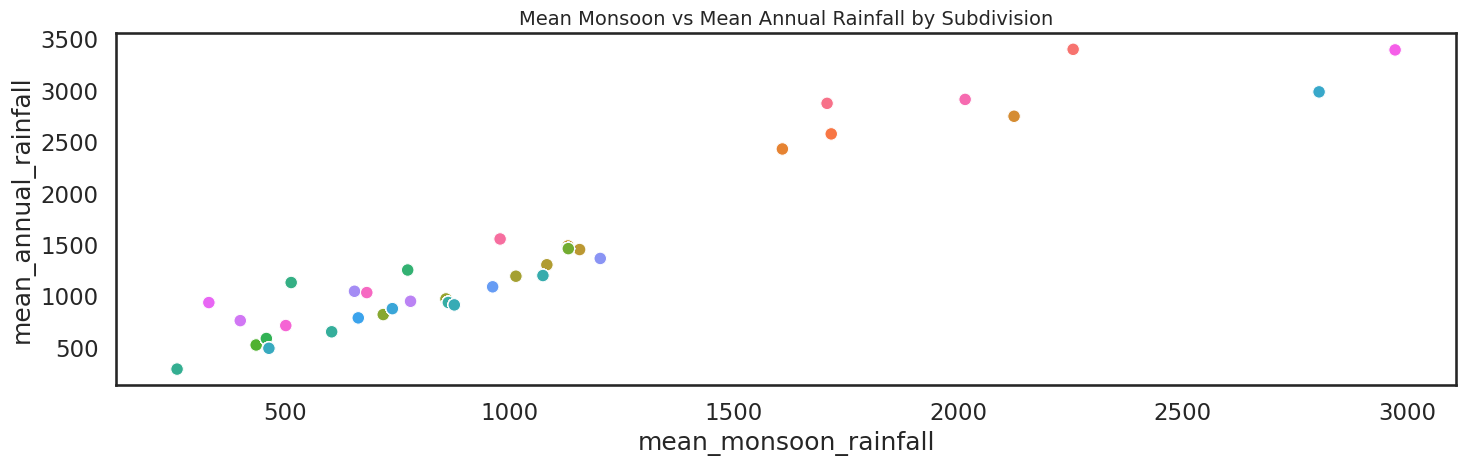

In [ ]:
plt.figure(figsize=(15,5))
sns.scatterplot(
    data=df,
    x='mean_monsoon_rainfall',
    y='mean_annual_rainfall',
    hue='subdivision',
    legend=False
)
plt.title('Mean Monsoon vs Mean Annual Rainfall by Subdivision', fontsize=14)
plt.tight_layout()
plt.show()

*Subdivisions with higher mean monsoon rainfall consistently show higher mean annual rainfall, reinforcing the dominant role of monsoon precipitation.  
The spread across subdivisions highlights regional climatic differences in rainfall dependency.*

**Rainfall Dependency on Monsoon Across Subdivisions**

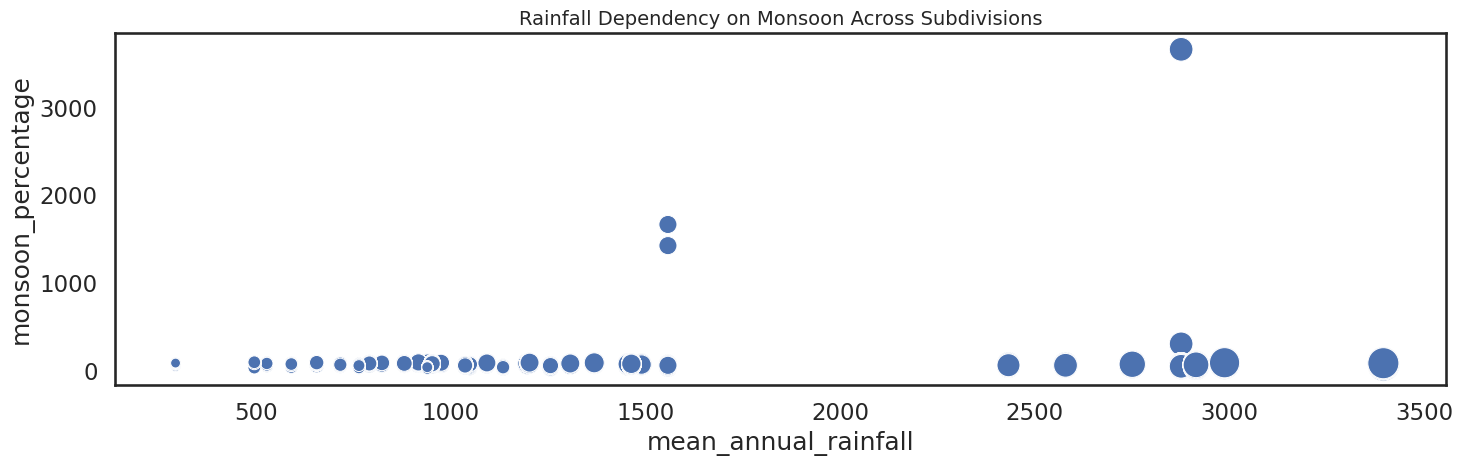

In [ ]:
plt.figure(figsize=(15,5))
sns.scatterplot(
    data=df,
    x='mean_annual_rainfall',
    y='monsoon_percentage',
    size='mean_monsoon_rainfall',
    sizes=(50, 500),
    legend=False
)
plt.title('Rainfall Dependency on Monsoon Across Subdivisions', fontsize=14)
plt.tight_layout()
plt.show()

*Regions with higher annual rainfall also exhibit a higher dependence on monsoon rainfall.  
The bubble size further emphasizes that subdivisions receiving intense monsoon rainfall contribute significantly to total annual precipitation.*

**Annual Rainfall Distribution by Monsoon Dependency**

In [ ]:
df['monsoon_dependency'] = pd.cut(
    df['monsoon_percentage'],
    bins=[0,50,70,100],
    labels=['Low','Moderate','High']
)

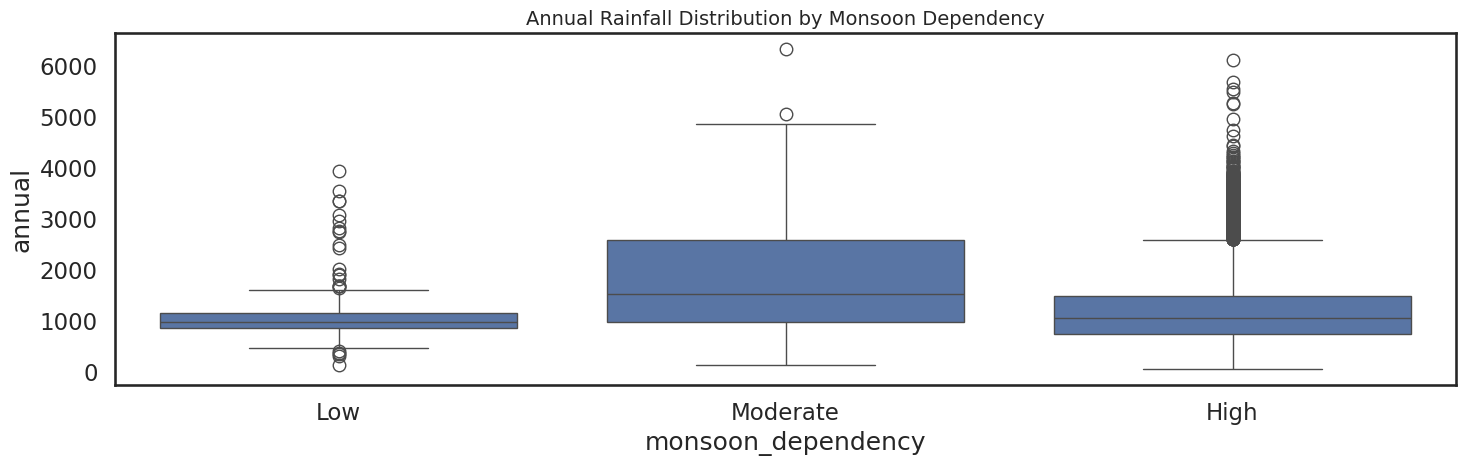

In [ ]:
plt.figure(figsize=(15,5))
sns.boxplot(
    data=df,
    x='monsoon_dependency',
    y='annual'
)
plt.title('Annual Rainfall Distribution by Monsoon Dependency', fontsize=14)
plt.tight_layout()
plt.show()


*Subdivisions classified under high monsoon dependency exhibit higher median annual rainfall along with greater variability.  
This indicates increased vulnerability to monsoon fluctuations in highly dependent regions.*

#**INSIGHT AND FINAL REPORT**

###**Objective of the Analysis**

The objective of this project is to analyze rainfall patterns across Indian subdivisions to understand spatial, seasonal, and temporal variability in precipitation. Through systematic data preprocessing and exploratory data analysis (EDA), the study aims to identify the dominant role of monsoon rainfall, regional disparities, and long-term variability in rainfall behavior to support climate-related assessment and planning.

###**Summary of Data Preparation**

* The rainfall dataset was systematically preprocessed to ensure accuracy, consistency, and suitability for exploratory analysis.

* The dataset contains subdivision-wise annual and seasonal rainfall records collected over multiple years, capturing both spatial and temporal variations in precipitation.

* Initial inspection was performed to understand the dataset structure, dimensions, and data types. All rainfall-related variables were verified and converted to appropriate numerical formats where required.

* Missing and inconsistent values were identified and carefully handled to preserve data reliability without distorting rainfall patterns.

* Extreme rainfall values were retained intentionally, as they represent climatologically important events such as intense monsoon years rather than data errors.

* New derived features were created, including rainfall intensity categories and monsoon contribution percentages, to enable clearer comparison across regions and time periods.

After preprocessing, the dataset was clean, consistent, and well-structured, enabling meaningful exploratory data analysis and reliable insight generation.

###**Summary of Key Insights on Rainfall Patterns**
* Monsoon Dominance: Monsoon rainfall accounts for a substantial majority of annual rainfall across most subdivisions, indicating strong seasonal dependence on the southwest monsoon.

* Annual Rainfall Variability: Annual rainfall exhibits noticeable inter-annual variability with a slightly right-skewed distribution, suggesting that while moderate rainfall years are common, extreme rainfall events occur intermittently.

* Regional Disparities: Western coastal and northeastern subdivisions consistently record higher annual and monsoon rainfall compared to inland and northwestern regions, highlighting the influence of geography and monsoon pathways.

* Monsoon–Annual Relationship: A strong positive relationship exists between monsoon rainfall and total annual rainfall, confirming that variability in annual rainfall is largely driven by monsoon performance rather than non-monsoon precipitation.

* Rainfall Categories: Rainfall classification effectively differentiates intensity levels, with higher rainfall categories exhibiting greater variability, indicating that extreme rainfall years are more dispersed and less predictable.

* Monsoon Dependency Risk: Subdivisions with high monsoon dependency show higher median annual rainfall along with increased variability, suggesting greater vulnerability to fluctuations in monsoon behavior.

* Long-Term Variability: Decadal analysis reveals fluctuations in average rainfall across different periods without a clear long-term linear trend, pointing to the influence of broader climatic variability rather than steady change.

###**Conclusion**

The rainfall analysis highlights the critical role of the monsoon in shaping India’s annual precipitation patterns. Rainfall behavior is characterized by strong seasonal dependence, pronounced regional variation, and significant inter-annual and multi-decadal variability. While most regions experience moderate rainfall levels, extreme events remain an important feature of the climatic system. The findings emphasize that changes in monsoon intensity and reliability can have widespread implications for water resources, agriculture, and climate resilience.

###**Recommendations**

* Strengthen monitoring and forecasting of monsoon rainfall to better anticipate variability and extreme events.

* Prioritize water resource planning in highly monsoon-dependent regions to reduce vulnerability to rainfall fluctuations.

* Incorporate regional rainfall variability into agricultural and infrastructure planning strategies.

* Extend long-term climate analysis to assess evolving rainfall behavior under changing climatic conditions.